In [1]:
from utils.plots import plot_tm_roc_curve_multi_specialist
import config
import pickle
import os
from utils.dataset import load_dataset

In [2]:
_, _, _, _, _, Y_test = load_dataset(config)


[Loading] BreastMNIST_Canny
  Class sums shape: (156, 2)
  Probs shape:      (156, 2)
  Probs sample (first 3 rows):
[[ 0.229       0.97285714]
 [ 0.229       0.454     ]
 [-0.42457143  1.55985714]]

[Loading] BreastMNIST_Adaptive_Gaussian
  Class sums shape: (156, 2)
  Probs shape:      (156, 2)
  Probs sample (first 3 rows):
[[ 0.4412      0.44413333]
 [ 0.0458      0.9766    ]
 [-0.1316      1.18906667]]

[Loading] BreastMNIST_Adaptive_Mean
  Class sums shape: (156, 2)
  Probs shape:      (156, 2)
  Probs sample (first 3 rows):
[[ 0.86473333 -0.0596    ]
 [ 0.31393333  0.74573333]
 [-0.47266667  1.4852    ]]

[Loading] BreastMNIST_Otsu
  Class sums shape: (156, 2)
  Probs shape:      (156, 2)
  Probs sample (first 3 rows):
[[ 0.61633333  0.32166667]
 [-0.42566667  0.98366667]
 [-0.182       1.37133333]]

[Loading] BreastMNIST_Color_Thermometers
  Class sums shape: (156, 2)
  Probs shape:      (156, 2)
  Probs sample (first 3 rows):
[[ 0.58225  0.54   ]
 [ 0.45575  0.75355]
 [-0.181

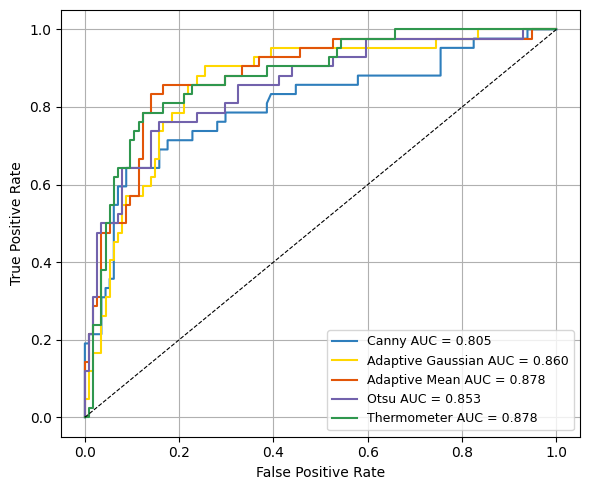


--- benign ---
Saved to breast_roc_benign.svg


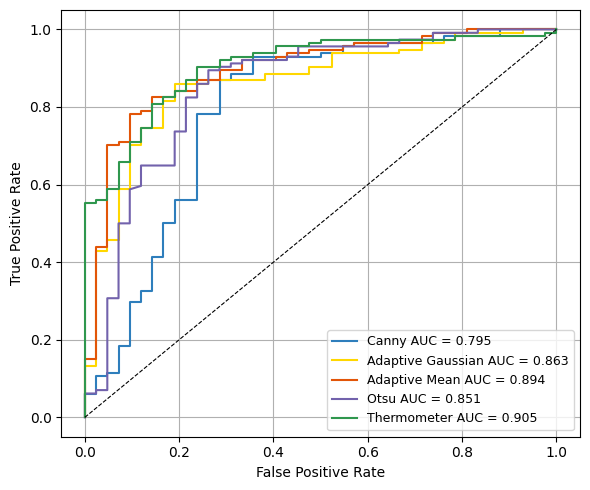

In [3]:

canny_path = os.path.join("saved_models", "BreastMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "BreastMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "BreastMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "BreastMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "BreastMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)
    
    
    
plot_tm_roc_curve_multi_specialist(
    config=config,
   params=[
        {"T_best": tm_canny.T, "s_best": tm_canny.s, "patch_best": tm_canny.patch_dim[0],
        "maxlit_best": tm_canny.max_included_literals, "weighted_best": 1},
        {"T_best": tm_gaussian.T, "s_best": tm_gaussian.s, "patch_best": tm_gaussian.patch_dim[0],
        "maxlit_best": tm_gaussian.max_included_literals, "weighted_best": 1},
        {"T_best": tm_mean.T, "s_best": tm_mean.s, "patch_best": tm_mean.patch_dim[0],
        "maxlit_best": tm_mean.max_included_literals, "weighted_best": 1},
        {"T_best": tm_otsu.T, "s_best": tm_otsu.s, "patch_best": tm_otsu.patch_dim[0],
        "maxlit_best": tm_otsu.max_included_literals, "weighted_best": 1},
        {"T_best": tm_thermo.T, "s_best": tm_thermo.s, "patch_best": tm_thermo.patch_dim[0],
        "maxlit_best": tm_thermo.max_included_literals, "weighted_best": 1},
    ],
        # ... repeat for each specialist

    filename_prefixes=[
        "BreastMNIST_Canny",
        "BreastMNIST_Adaptive_Gaussian",
        "BreastMNIST_Adaptive_Mean",
        "BreastMNIST_Otsu",
        "BreastMNIST_Color_Thermometers",
    ],
    specialist_names=["Canny", "Adaptive Gaussian", "Adaptive Mean", "Otsu", "Thermometer"],
    Y_test=Y_test,
    class_names=["malignant", "benign"],
    save_path="breast_roc.svg"
)